# Emotion Classification with Attention — LSTM vs GRU vs BiLSTM+Attention vs Fine-tuned Transformer (GoEmotions)

In [1]:
!pip install -q -U datasets evaluate accelerate gensim gradio transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 56.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 53.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 12.0 MB/s eta 0:00:00


In [2]:
import os, re, random, pickle, json, string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, f1_score, precision_recall_fscore_support, classification_report, confusion_matrix

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

os.makedirs("models", exist_ok=True)

cuda


## 1. Load GoEmotions (Ekman grouping) and map to 6 target emotions

In [3]:
raw = load_dataset("google-research-datasets/go_emotions", "simplified")
print(raw)

FINE_LABELS = raw["train"].features["labels"].feature.names
print(FINE_LABELS)

EKMAN_MAPPING = {
    "anger": ["anger", "annoyance", "disapproval"],
    "disgust": ["disgust"],
    "fear": ["fear", "nervousness"],
    "joy": ["joy", "amusement", "approval", "excitement", "gratitude", "love",
            "optimism", "relief", "pride", "admiration", "desire", "caring"],
    "sadness": ["sadness", "disappointment", "embarrassment", "grief", "remorse"],
    "surprise": ["surprise", "realization", "confusion", "curiosity"],
}

TARGET_EMOTIONS = ["joy", "sadness", "anger", "fear", "surprise", "disgust"]

fine_id_to_ekman = {}
for ekman_cat, fine_names in EKMAN_MAPPING.items():
    for fname in fine_names:
        if fname in FINE_LABELS:
            fine_id_to_ekman[FINE_LABELS.index(fname)] = ekman_cat

def to_single_label(example):
    cats = {fine_id_to_ekman[l] for l in example["labels"] if l in fine_id_to_ekman}
    example["single_label"] = list(cats)[0] if len(cats) == 1 else None
    return example

def build_df(split):
    ds = raw[split].map(to_single_label)
    df = ds.to_pandas()
    df = df[df["single_label"].notna()].copy()
    df = df.rename(columns={"single_label": "emotion"})
    return df[["text", "emotion"]].reset_index(drop=True)

train_df = build_df("train")
val_df = build_df("validation")
test_df = build_df("test")
print(train_df.shape, val_df.shape, test_df.shape)
train_df.head()

README.md:   0%|          | 0.00/9.40k [00:00<?, ?B/s]

simplified/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 2.77MB            

simplified/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

simplified/validation-00000-of-00001.par(…): reconstructing file:   0%|          |  0.00B /  350kB            

simplified/validation-00000-of-00001.par(…): downloading bytes:           |  0.00B            

...

Map:   0%|          | 0/43410 [00:00<?, ? examples/s]

Map:   0%|          | 0/5426 [00:00<?, ? examples/s]

Map:   0%|          | 0/5427 [00:00<?, ? examples/s]

(28104, 2) (3527, 2) (3539, 2)


,text,emotion
0,WHY THE FUCK IS BAYLESS ISOING,anger
1,To make her feel threatened,fear
2,Dirty Southern Wankers,anger
3,OmG pEyToN iSn'T gOoD eNoUgH tO hElP uS iN tHe...,surprise
4,Yes I heard abt the f bombs! That has to be wh...,joy


## 2. EDA — class distribution

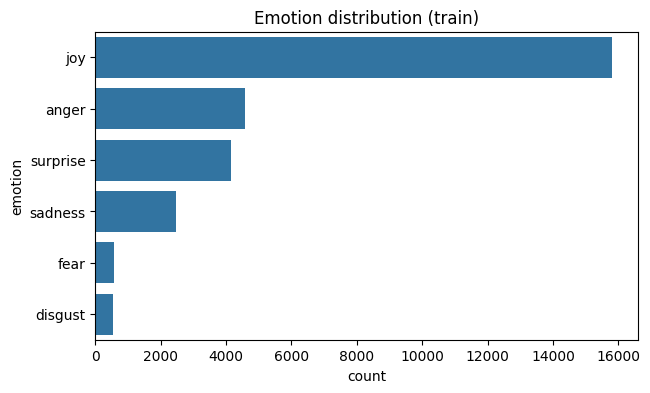

emotion
joy         0.562518
anger       0.163322
surprise    0.148022
sadness     0.087354
fear        0.020139
disgust     0.018645
Name: proportion, dtype: float64


In [4]:
plt.figure(figsize=(7,4))
sns.countplot(data=train_df, y="emotion", order=train_df["emotion"].value_counts().index)
plt.title("Emotion distribution (train)")
plt.show()
print(train_df["emotion"].value_counts(normalize=True))

## 3. Text cleaning

In [5]:
PUNCT_TABLE = str.maketrans("", "", string.punctuation)

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"\[name\]|\[religion\]", " ", text)
    text = text.translate(PUNCT_TABLE)
    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

for d in (train_df, val_df, test_df):
    d["clean_text"] = d["text"].apply(clean_text)
    d.drop(d[d["clean_text"].str.len() == 0].index, inplace=True)
    d.reset_index(drop=True, inplace=True)

train_df[["text", "clean_text"]].head()

,text,clean_text
0,WHY THE FUCK IS BAYLESS ISOING,why the fuck is bayless isoing
1,To make her feel threatened,to make her feel threatened
2,Dirty Southern Wankers,dirty southern wankers
3,OmG pEyToN iSn'T gOoD eNoUgH tO hElP uS iN tHe...,omg peyton isnt good enough to help us in the ...
4,Yes I heard abt the f bombs! That has to be wh...,yes i heard abt the f bombs that has to be why...


## 4. Label encoding

In [6]:
label2id = {e: i for i, e in enumerate(TARGET_EMOTIONS)}
id2label = {i: e for e, i in label2id.items()}
NUM_CLASSES = len(TARGET_EMOTIONS)

for d in (train_df, val_df, test_df):
    d["label_id"] = d["emotion"].map(label2id)

with open("models/label_list.pkl", "wb") as f:
    pickle.dump(TARGET_EMOTIONS, f)

## 5. Vocabulary + pre-trained GloVe embeddings

In [7]:
from collections import Counter

word_counter = Counter()
for text in train_df["clean_text"]:
    word_counter.update(text.split())

PAD, UNK = "<PAD>", "<UNK>"
word2idx = {PAD: 0, UNK: 1}
for w, c in word_counter.most_common(30000):
    word2idx[w] = len(word2idx)

VOCAB_SIZE = len(word2idx)
with open("models/word2idx.pkl", "wb") as f:
    pickle.dump(word2idx, f)

import gensim.downloader as gensim_api
glove = gensim_api.load("glove-wiki-gigaword-100")
EMBED_DIM = 100

embedding_matrix = np.random.normal(scale=0.1, size=(VOCAB_SIZE, EMBED_DIM)).astype(np.float32)
embedding_matrix[0] = np.zeros(EMBED_DIM)
hits = 0
for w, idx in word2idx.items():
    if w in glove.key_to_index:
        embedding_matrix[idx] = glove[w]
        hits += 1
print(f"GloVe coverage: {hits}/{VOCAB_SIZE}")

[==================================================] 100.0% 128.1/128.1MB downloaded
GloVe coverage: 17412/21470


## 6. PyTorch Dataset + padding

In [8]:
MAX_LEN = 40

def encode(text):
    ids = [word2idx.get(w, word2idx[UNK]) for w in text.split()][:MAX_LEN]
    ids = ids + [0] * (MAX_LEN - len(ids))
    length = min(len(text.split()), MAX_LEN)
    return ids, length

class EmotionDataset(Dataset):
    def __init__(self, df):
        self.texts = df["clean_text"].tolist()
        self.labels = df["label_id"].tolist()

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, i):
        ids, length = encode(self.texts[i])
        return torch.tensor(ids), torch.tensor(length), torch.tensor(self.labels[i])

BATCH_SIZE = 64
train_loader = DataLoader(EmotionDataset(train_df), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(EmotionDataset(val_df), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(EmotionDataset(test_df), batch_size=BATCH_SIZE, shuffle=False)

class_weights_arr = compute_class_weight(class_weight="balanced", classes=np.arange(NUM_CLASSES), y=train_df["label_id"].values)
class_weights = torch.tensor(class_weights_arr, dtype=torch.float32).to(device)
print(class_weights)

tensor([0.2963, 1.9077, 1.0206, 8.2744, 1.1258, 8.9547], device='cuda:0')


## 7. Model architectures

In [9]:
class RNNClassifier(nn.Module):
    def __init__(self, embedding_matrix, num_classes, cell="lstm", hidden_dim=128):
        super().__init__()
        vocab_size, embed_dim = embedding_matrix.shape
        self.embed = nn.Embedding.from_pretrained(torch.tensor(embedding_matrix), freeze=False, padding_idx=0)
        rnn_cls = nn.LSTM if cell == "lstm" else nn.GRU
        self.rnn = rnn_cls(embed_dim, hidden_dim, batch_first=True)
        self.dropout = nn.Dropout(0.4)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x, lengths):
        emb = self.embed(x)
        packed = nn.utils.rnn.pack_padded_sequence(emb, lengths.cpu(), batch_first=True, enforce_sorted=False)
        out, hidden = self.rnn(packed)
        h = hidden[0][-1] if isinstance(hidden, tuple) else hidden[-1]
        h = self.dropout(h)
        return self.fc(h)


class AdditiveAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim, hidden_dim)
        self.context = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, hidden_states, mask):
        energy = torch.tanh(self.attn(hidden_states))
        scores = self.context(energy).squeeze(-1)
        scores = scores.masked_fill(~mask, float("-inf"))
        weights = torch.softmax(scores, dim=-1)
        context = torch.bmm(weights.unsqueeze(1), hidden_states).squeeze(1)
        return context, weights


class BiLSTMAttention(nn.Module):
    def __init__(self, embedding_matrix, num_classes, hidden_dim=128):
        super().__init__()
        vocab_size, embed_dim = embedding_matrix.shape
        self.embed = nn.Embedding.from_pretrained(torch.tensor(embedding_matrix), freeze=False, padding_idx=0)
        self.bilstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.attention = AdditiveAttention(hidden_dim * 2)
        self.dropout = nn.Dropout(0.4)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x, lengths):
        mask = (x != 0)
        emb = self.embed(x)
        packed = nn.utils.rnn.pack_padded_sequence(emb, lengths.cpu(), batch_first=True, enforce_sorted=False)
        packed_out, _ = self.bilstm(packed)
        out, _ = nn.utils.rnn.pad_packed_sequence(packed_out, batch_first=True, total_length=x.shape[1])
        context, weights = self.attention(out, mask)
        context = self.dropout(context)
        return self.fc(context), weights

## 8. Generic training + evaluation

In [10]:
results = {}

def evaluate_model(model, loader, has_attention=False):
    model.eval()
    all_preds, all_trues = [], []
    with torch.no_grad():
        for x, lengths, y in loader:
            x, lengths, y = x.to(device), lengths.to(device), y.to(device)
            out = model(x, lengths)
            logits = out[0] if has_attention else out
            preds = torch.argmax(logits, dim=-1)
            all_preds.extend(preds.cpu().tolist())
            all_trues.extend(y.cpu().tolist())
    return all_preds, all_trues

def train_and_eval(name, model, epochs=8, lr=1e-3, has_attention=False):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss(weight=class_weights)
    best_f1, best_state = -1, None

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for x, lengths, y in train_loader:
            x, lengths, y = x.to(device), lengths.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x, lengths)
            logits = out[0] if has_attention else out
            loss = loss_fn(logits, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        val_preds, val_trues = evaluate_model(model, val_loader, has_attention)
        val_f1 = f1_score(val_trues, val_preds, average="macro")
        print(f"[{name}] epoch {epoch+1}/{epochs} loss={total_loss/len(train_loader):.4f} val_macro_f1={val_f1:.4f}")
        if val_f1 > best_f1:
            best_f1 = val_f1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    torch.save(best_state, f"models/best_{name}.pt")

    test_preds, test_trues = evaluate_model(model, test_loader, has_attention)
    acc = accuracy_score(test_trues, test_preds)
    prec, rec, f1, _ = precision_recall_fscore_support(test_trues, test_preds, average="macro")
    print(f"\n=== {name.upper()} — test set ===")
    print(classification_report(test_trues, test_preds, target_names=TARGET_EMOTIONS, digits=4))

    cm = confusion_matrix(test_trues, test_preds)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=TARGET_EMOTIONS, yticklabels=TARGET_EMOTIONS, cmap="Blues")
    plt.title(f"Confusion Matrix — {name.upper()}")
    plt.xlabel("Predicted"); plt.ylabel("True")
    plt.show()

    results[name] = {"accuracy": acc, "precision": prec, "recall": rec, "macro_f1": f1}
    return model

## 9. Train LSTM

[lstm] epoch 1/8 loss=1.5277 val_macro_f1=0.4421
[lstm] epoch 2/8 loss=1.0274 val_macro_f1=0.5675
[lstm] epoch 3/8 loss=0.7897 val_macro_f1=0.6094
[lstm] epoch 4/8 loss=0.6316 val_macro_f1=0.5823
[lstm] epoch 5/8 loss=0.4930 val_macro_f1=0.5750
[lstm] epoch 6/8 loss=0.3755 val_macro_f1=0.5829
[lstm] epoch 7/8 loss=0.2865 val_macro_f1=0.5785
[lstm] epoch 8/8 loss=0.2306 val_macro_f1=0.5847

=== LSTM — test set ===
              precision    recall  f1-score   support

         joy     0.8951    0.7842    0.8360      1937
     sadness     0.5185    0.6577    0.5799       298
       anger     0.5501    0.6043    0.5759       609
        fear     0.6329    0.5882    0.6098        85
    surprise     0.5512    0.6360    0.5906       533
     disgust     0.4653    0.6104    0.5281        77

    accuracy                         0.7118      3539
   macro avg     0.6022    0.6468    0.6200      3539
weighted avg     0.7366    0.7118    0.7206      3539



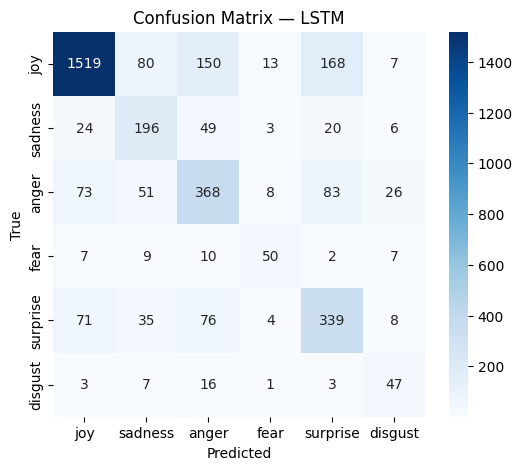

In [11]:
lstm_model = RNNClassifier(embedding_matrix, NUM_CLASSES, cell="lstm")
lstm_model = train_and_eval("lstm", lstm_model, has_attention=False)

## 10. Train GRU

[gru] epoch 1/8 loss=1.4179 val_macro_f1=0.5099
[gru] epoch 2/8 loss=0.9295 val_macro_f1=0.5702
[gru] epoch 3/8 loss=0.7383 val_macro_f1=0.5528
[gru] epoch 4/8 loss=0.5870 val_macro_f1=0.5937
[gru] epoch 5/8 loss=0.4400 val_macro_f1=0.5874
[gru] epoch 6/8 loss=0.3315 val_macro_f1=0.5812
[gru] epoch 7/8 loss=0.2452 val_macro_f1=0.5783
[gru] epoch 8/8 loss=0.1962 val_macro_f1=0.5683

=== GRU — test set ===
              precision    recall  f1-score   support

         joy     0.9213    0.7553    0.8301      1937
     sadness     0.5093    0.6409    0.5676       298
       anger     0.5954    0.5484    0.5709       609
        fear     0.5197    0.7765    0.6226        85
    surprise     0.5087    0.7148    0.5944       533
     disgust     0.3669    0.6623    0.4722        77

    accuracy                         0.7025      3539
   macro avg     0.5702    0.6831    0.6096      3539
weighted avg     0.7467    0.7025    0.7151      3539



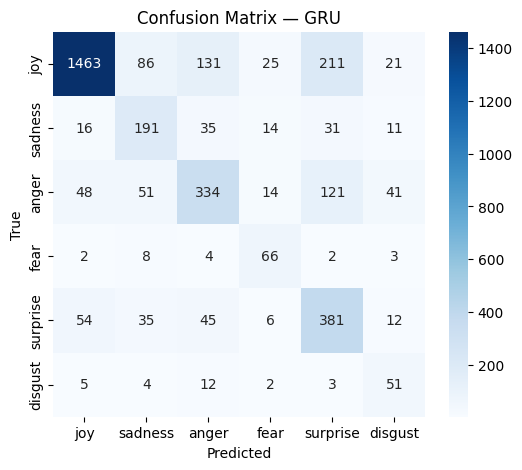

In [12]:
gru_model = RNNClassifier(embedding_matrix, NUM_CLASSES, cell="gru")
gru_model = train_and_eval("gru", gru_model, has_attention=False)

## 11. Train BiLSTM + Attention

[bilstm_attention] epoch 1/8 loss=1.2397 val_macro_f1=0.5548
[bilstm_attention] epoch 2/8 loss=0.8657 val_macro_f1=0.5573
[bilstm_attention] epoch 3/8 loss=0.7327 val_macro_f1=0.6241
[bilstm_attention] epoch 4/8 loss=0.5971 val_macro_f1=0.6036
[bilstm_attention] epoch 5/8 loss=0.4777 val_macro_f1=0.6030
[bilstm_attention] epoch 6/8 loss=0.3551 val_macro_f1=0.6199
[bilstm_attention] epoch 7/8 loss=0.2716 val_macro_f1=0.5944
[bilstm_attention] epoch 8/8 loss=0.2090 val_macro_f1=0.6094

=== BILSTM_ATTENTION — test set ===
              precision    recall  f1-score   support

         joy     0.9187    0.7816    0.8446      1937
     sadness     0.5663    0.6309    0.5968       298
       anger     0.6206    0.5829    0.6012       609
        fear     0.5512    0.8235    0.6604        85
    surprise     0.5186    0.7073    0.5984       533
     disgust     0.3910    0.6753    0.4952        77

    accuracy                         0.7222      3539
   macro avg     0.5944    0.7003    0.63

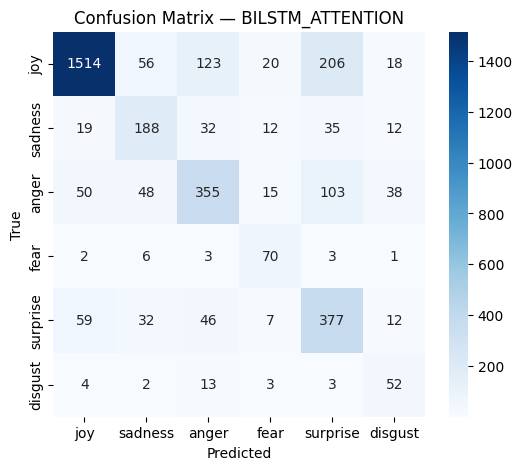

In [13]:
bilstm_attn_model = BiLSTMAttention(embedding_matrix, NUM_CLASSES)
bilstm_attn_model = train_and_eval("bilstm_attention", bilstm_attn_model, has_attention=True)

## 12. Attention heatmaps — which words drive each prediction

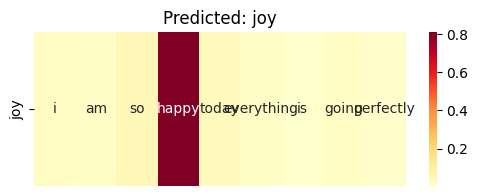

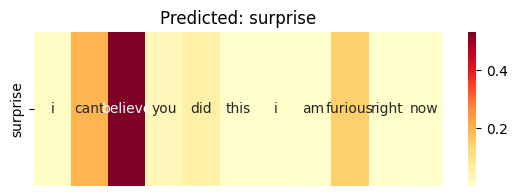

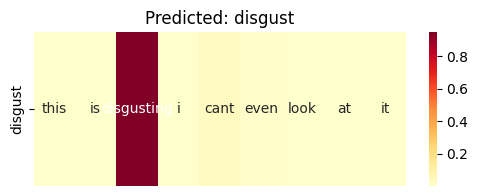

In [14]:
def plot_attention(text, model=bilstm_attn_model):
    model.eval()
    cleaned = clean_text(text)
    tokens = cleaned.split()[:MAX_LEN]
    ids, length = encode(cleaned)
    x = torch.tensor([ids]).to(device)
    lengths = torch.tensor([length]).to(device)
    with torch.no_grad():
        logits, weights = model(x, lengths)
    pred = id2label[int(torch.argmax(logits, dim=-1)[0])]
    w = weights[0][:len(tokens)].cpu().numpy()

    plt.figure(figsize=(max(6, len(tokens) * 0.6), 2))
    sns.heatmap(w.reshape(1, -1), annot=[tokens], fmt="", cmap="YlOrRd", cbar=True, xticklabels=False, yticklabels=[pred])
    plt.title(f"Predicted: {pred}")
    plt.show()

for sample_text in [
    "I am so happy today, everything is going perfectly!",
    "I can't believe you did this, I am furious right now.",
    "This is disgusting, I can't even look at it.",
]:
    plot_attention(sample_text)

## 13. Fine-tune HuggingFace Transformer

In [15]:
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, DataCollatorWithPadding
)
from datasets import Dataset
import evaluate

MODEL_NAME = "distilbert-base-uncased"
hf_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

hf_train_ds = Dataset.from_pandas(train_df[["clean_text", "label_id"]].rename(columns={"clean_text": "text", "label_id": "label"}))
hf_val_ds = Dataset.from_pandas(val_df[["clean_text", "label_id"]].rename(columns={"clean_text": "text", "label_id": "label"}))
hf_test_ds = Dataset.from_pandas(test_df[["clean_text", "label_id"]].rename(columns={"clean_text": "text", "label_id": "label"}))

def tokenize_fn(batch):
    return hf_tokenizer(batch["text"], truncation=True, max_length=64)

hf_train_ds = hf_train_ds.map(tokenize_fn, batched=True)
hf_val_ds = hf_val_ds.map(tokenize_fn, batched=True)
hf_test_ds = hf_test_ds.map(tokenize_fn, batched=True)

data_collator = DataCollatorWithPadding(tokenizer=hf_tokenizer)
hf_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=NUM_CLASSES, id2label=id2label, label2id=label2id
)

accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_metric.compute(predictions=preds, references=labels)["accuracy"]
    f1 = f1_metric.compute(predictions=preds, references=labels, average="macro")["f1"]
    return {"accuracy": acc, "macro_f1": f1}

training_args = TrainingArguments(
    output_dir="models/transformer_ckpts",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    num_train_epochs=4,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    fp16=torch.cuda.is_available(),
    report_to="none",
)

trainer = Trainer(
    model=hf_model,
    args=training_args,
    train_dataset=hf_train_ds,
    eval_dataset=hf_val_ds,
    processing_class=hf_tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer.train()

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/28100 [00:00<?, ? examples/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=3516, training_loss=0.46923890123323914, metrics={'train_runtime': 172.1053, 'train_samples_per_second': 653.089, 'train_steps_per_second': 20.429, 'total_flos': 887288529746304.0, 'train_loss': 0.46923890123323914, 'epoch': 4.0})

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TRANSFORMER — acc=0.8025 macro_f1=0.6934
              precision    recall  f1-score   support

         joy     0.8808    0.9231    0.9014      1937
     sadness     0.6728    0.6141    0.6421       298
       anger     0.6849    0.6782    0.6815       609
        fear     0.6327    0.7294    0.6776        85
    surprise     0.7453    0.6698    0.7055       533
     disgust     0.6491    0.4805    0.5522        77

    accuracy                         0.8025      3539
   macro avg     0.7109    0.6825    0.6934      3539
weighted avg     0.7982    0.8025    0.7993      3539



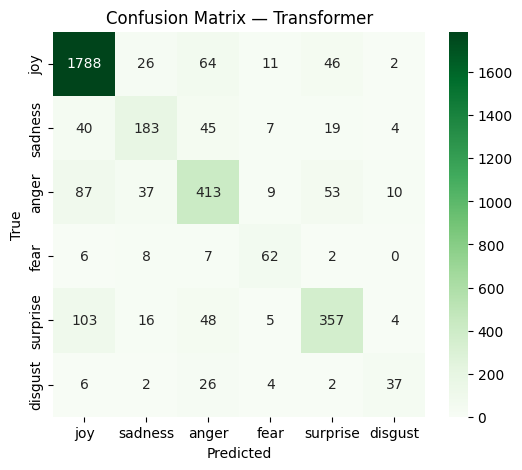

In [16]:
best_transformer_dir = "models/best_transformer"
trainer.save_model(best_transformer_dir)
hf_tokenizer.save_pretrained(best_transformer_dir)

test_preds_out = trainer.predict(hf_test_ds)
y_pred_hf = np.argmax(test_preds_out.predictions, axis=-1)
y_true_hf = test_df["label_id"].values

acc = accuracy_score(y_true_hf, y_pred_hf)
prec, rec, f1, _ = precision_recall_fscore_support(y_true_hf, y_pred_hf, average="macro")
print(f"TRANSFORMER — acc={acc:.4f} macro_f1={f1:.4f}")
print(classification_report(y_true_hf, y_pred_hf, target_names=TARGET_EMOTIONS, digits=4))

cm = confusion_matrix(y_true_hf, y_pred_hf)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=TARGET_EMOTIONS, yticklabels=TARGET_EMOTIONS, cmap="Greens")
plt.title("Confusion Matrix — Transformer")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.show()

results["transformer"] = {"accuracy": acc, "precision": prec, "recall": rec, "macro_f1": f1}

## 14. Compare all four architectures

                  accuracy  precision    recall  macro_f1
transformer       0.802487   0.710928  0.682509  0.693405
bilstm_attention  0.722238   0.594385  0.700265  0.632778
lstm              0.711783   0.602197  0.646806  0.620036
gru               0.702458   0.570209  0.683050  0.609644


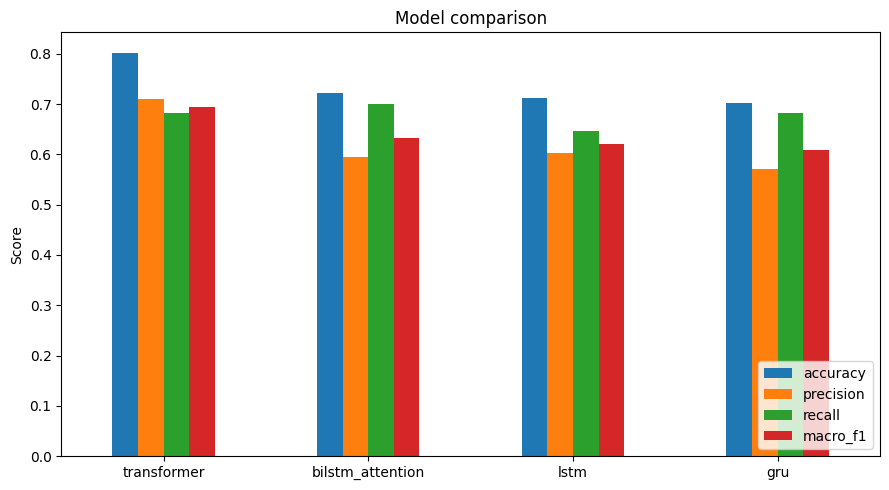

Best model: transformer


In [17]:
results_df = pd.DataFrame(results).T.sort_values("macro_f1", ascending=False)
print(results_df)

results_df.plot(kind="bar", figsize=(9,5))
plt.title("Model comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

with open("models/results_summary.json", "w") as f:
    json.dump(results, f, indent=2)

best_model_name = results_df.index[0]
print("Best model:", best_model_name)

## 15. Gradio app — dominant emotion + confidence bar chart

In [18]:
import gradio as gr

def predict_proba(text, model_choice):
    model_choice = best_model_name if model_choice == "Best model" else model_choice
    cleaned = clean_text(text)

    if model_choice == "transformer":
        tok = AutoTokenizer.from_pretrained(best_transformer_dir)
        model = AutoModelForSequenceClassification.from_pretrained(best_transformer_dir).to(device).eval()
        inputs = tok(cleaned, return_tensors="pt", truncation=True, max_length=64).to(device)
        with torch.no_grad():
            logits = model(**inputs).logits
        probs = torch.softmax(logits, dim=-1)[0].cpu().numpy()
    else:
        ids, length = encode(cleaned)
        x = torch.tensor([ids]).to(device)
        lengths = torch.tensor([length]).to(device)
        if model_choice == "lstm":
            model = lstm_model.eval()
            logits = model(x, lengths)
        elif model_choice == "gru":
            model = gru_model.eval()
            logits = model(x, lengths)
        else:
            model = bilstm_attn_model.eval()
            logits, _ = model(x, lengths)
        probs = torch.softmax(logits, dim=-1)[0].detach().cpu().numpy()

    return {TARGET_EMOTIONS[i]: float(probs[i]) for i in range(NUM_CLASSES)}

model_options = ["Best model", "lstm", "gru", "bilstm_attention", "transformer"]

demo = gr.Interface(
    fn=predict_proba,
    inputs=[
        gr.Textbox(lines=4, label="Enter text", placeholder="Type a sentence to detect its dominant emotion..."),
        gr.Dropdown(model_options, value="Best model", label="Model"),
    ],
    outputs=gr.Label(num_top_classes=6, label="Emotion confidence"),
    title="Emotion Classifier",
    description="LSTM / GRU / BiLSTM+Attention / Fine-tuned Transformer — GoEmotions (Ekman grouping)",
)

demo.launch(share=True, debug=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://45e1c3fdd897850fec.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
